# Regression, Regularization, and Gradient Descent

$Author$: Michael Simons

$Class$: CSE 474 - Machine Learning

$Date$: 06/15/23

## Linear Regression ##

This section will utilize insight from our prior analysis of the diamonds dataset to build a prediction model. Our goal is to predict the price of a diamond given a combination of its features. We will begin by extracting and preprocessing, and gathering statistics of the dataset using the describe method. In preprocessing, we will convert each non-numerical feature to a categorical type, and add a bias column w0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
diamond_data = pd.read_csv('datasets/diamonds.csv') #Extract diamond data

#Convert string types to categorical
diamond_data['cut'] = diamond_data['cut'].astype('category')
diamond_data['color'] = diamond_data['color'].astype('category')
diamond_data['clarity'] = diamond_data['clarity'].astype('category')
diamond_data['w0'] = 1    #Add implicit bias column
diamond_data.drop(columns=['w0', 'Unnamed: 0']).describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


We will now select the target column from the dataset, which is the attribute we are trying to predict, the price of a diamond.

In [2]:
target_column = np.array(diamond_data['price']).reshape(-1,1)

It is now necessary to select the input columns. Given our prior analysis of the diamond dataset, an appropriate combination of input columns is color, cut, carat, x, and y. This is because our analysis revealed a high correlation between price and these features. Since color and cut are categorical feature, we will encode color and cut using integers.

In [3]:
#Encode categorical features
diamond_data['cut_encoded'] = diamond_data['cut'].cat.codes
diamond_data['color_encoded'] = diamond_data['color'].cat.codes

input_columns = np.array(diamond_data[['w0','carat','x','y','color_encoded','cut_encoded']])  #Select input columns

With our target column and input columns defined, the data will now be split into training and testing data. 80% of samples will be used in training, and the remaining 20% of samples will be used to test the model's predictions.

In [4]:
eighty_pct_idx = int(0.8*len(input_columns)) #Compute the train/test split index

x_train = input_columns[:eighty_pct_idx] #First 80% of input columns
x_test = input_columns[eighty_pct_idx:]  #Last 20% of input columns
y_train = target_column[:eighty_pct_idx] #First 80% of target column
y_test = target_column[eighty_pct_idx:] #Last 20% of target column

print(f'x_train shape: {x_train.shape}\ny_train shape: {y_train.shape}\n\nx_test shape: {x_test.shape}\ny_test shape: {y_test.shape}')

x_train shape: (43152, 6)
y_train shape: (43152, 1)

x_test shape: (10788, 6)
y_test shape: (10788, 1)


The dataset has properly been fit into training and testing sets. The training data will now be utilized to calculate weights using the OLS equation: 

$w = (X^{T}X)^{-1}X^{T}y$

In [5]:
xT_dot_x = np.dot(x_train.T,x_train) #Compute X^TX
invert = np.linalg.inv(xT_dot_x)     #Invert X^TX
xT_dot_y = np.dot(x_train.T,y_train) #Compute X^Ty
weights = np.dot(invert,xT_dot_y)    #Multiply inverted x^TX with X^Ty to produce weights
weights

array([[ 1630.67147608],
       [10138.75196885],
       [-1038.39601057],
       [  126.08840979],
       [ -286.73895573],
       [  105.47393602]])

With the weights successfully computed, predictions can be produced by applying them to the testing data.

In [6]:
predictions = np.dot(x_test,weights) #Acquire predictions
predictions.shape, y_test.shape #Compare shapes

((10788, 1), (10788, 1))

The predictions are properly formatted. The RMSE will now be computed using the following formula:

$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$

where $n$ is the amount of predictions, $\hat{y}_i$ is the predicted price of a diamond $i$, and $y_i$ is the actual price.

In [7]:
mean_squared_error = np.mean((y_test-predictions)**2) #Compute MSE
rmse = np.sqrt(mean_squared_error) #Take sqrt of MSE
print(f"RMSE (Linear regression): {rmse}")

RMSE (Linear regression): 797.294191828186


The high RMSE value indicates that our prediction model may not be completely capturing the underlying patterns in the data, and will certainly require further regularization to improve. Nonetheless, we will visually compare the predicted diamond prices to their actual prices. Doing so will require us to sort our entries as well as our predictions.

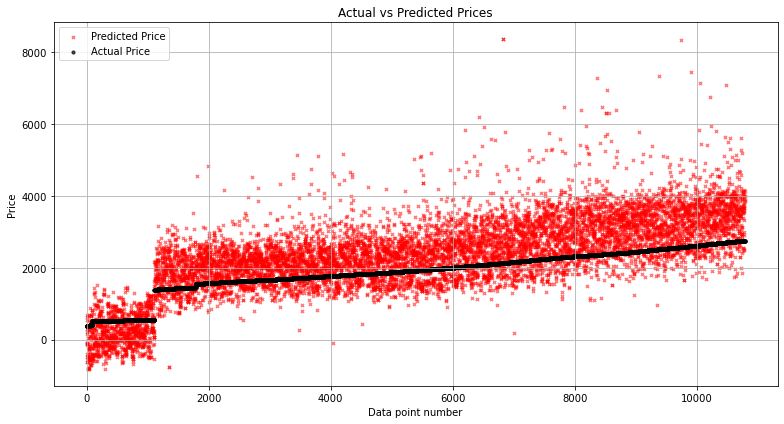

In [8]:
sorted_indices = np.argsort(y_test.flatten()) #Gather a soted order of indices
sorted_y_test = y_test[sorted_indices] #Apply the sorting to y_test
sorted_predictions = predictions[sorted_indices] #Applythe sorting to the predictions

#Produce scatter plot displaying actual price vs predicted price.
plt.figure(figsize=(11, 6))  # Increase the figure size for better visibility
plt.scatter(range(len(sorted_predictions)), sorted_predictions, color='red', label='Predicted Price', s=10, alpha=0.5, marker='x')
plt.scatter(range(len(sorted_y_test)), sorted_y_test, color='k', label='Actual Price', s=10, alpha=0.7, marker='o')

plt.xlabel('Data point number')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()  # Adjust the spacing of the plot to allow for more clarity
plt.grid()  # Add grid lines

The scatterplot shows that the variance of our predictions appears to be extremely high, and the model is even predicting negative prices in some cases. As previously indicated, our model has a clear need for regularization. In the following section, our implementation will be extended to incorporate ridge regression. This is likely to drastically improve our model by lessening the variance of our predictions.

## Ridge Regression ##

In order to address the high variance and potential overfitting observed in our linear regression model, we will now extend our implementation to incorporate ridge regression. Ridge regression introduces a penalty term to the least squares equation, effectively constraining the weights and reducing their magnitude. The OLS equation for ridge regression can be estimated as:

$w = (X^{T}X+λI)^{-1}X^{T}y$

A function which encodes this algorithm will be written. This will allow us to evaluate the performance with different values of λ.

In [9]:
#Given a lambda value, compute the ridge weights based on the diamond training data.
def ridge_reg(inputs, targets, λ):
    xT_dot_x = np.dot(inputs.T, inputs)          #Compute x^Tx
    reg_term = λ*np.identity(inputs.shape[1])    #Apply regularization
    invert = np.linalg.inv(xT_dot_x + reg_term)  #Invert(x^Tx + lambda*I)
    xT_dot_y = np.dot(inputs.T, targets)         #Compute X^Ty
    return np.dot(invert, xT_dot_y)              #Return inverted (X^TX + λI) multiplied with X^Ty

The model's predictions will now be evaluated using 5,000 different lambda values, each selected linearly from the interval -10,000 to 10,000. The performances will be compared to compute which value of lambda produces the best performance.

In [10]:
import math
lambda_candidates = np.linspace(-10000,10000,5000) #Initialize list of lambda values to test
lowest_squared_loss = math.inf #Initialize best loss tracker
best_lambda_value = None #Initialize best lambda tracker

for L in lambda_candidates: #Iterate through test values
    ridge_model = ridge_reg(x_train,y_train,L)
    predictions = np.dot(x_test,ridge_model) #Generate predictions
    mean_squared_loss = np.mean( (y_test - predictions) **2) #Compute squared loss
    if mean_squared_loss<lowest_squared_loss: #Update if new best value has been found
        lowest_squared_loss = mean_squared_loss
        best_lambda_value = L

#Display Results
print(f'Best λ value: {best_lambda_value}')
print(f'Mean squared loss: {lowest_squared_loss}')
print(f'RMSE: {np.sqrt(lowest_squared_loss)}')

Best λ value: -70.01400280056077
Mean squared loss: 514219.65444615047
RMSE: 717.0911060989046


The value of lambda which produced the least amount of error was about -70, which indicates that it may be a good tuning for the model. Although the loss is still considerable, incorporating ridge regression has improved the accuracy of the predictions.

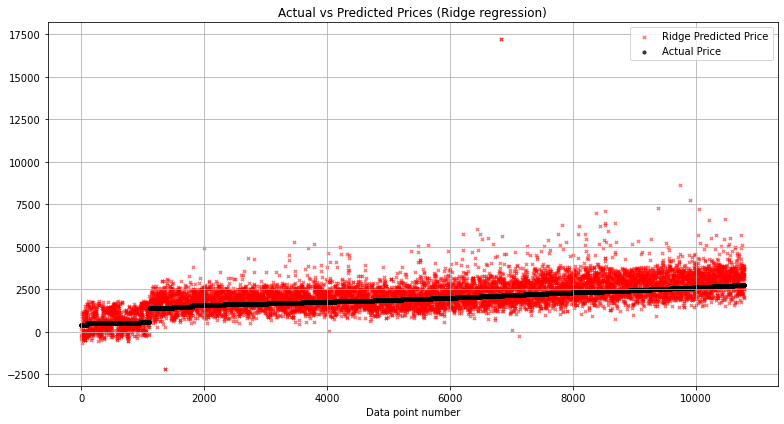

In [25]:
predictions = np.dot(x_test,ridge_reg(x_train,y_train,-70))
sorted_y_test = y_test[sorted_indices] #Apply the sorting to y_test
sorted_ridge_predictions = predictions[sorted_indices]  # Apply the sorting to ridge predictions

# Produce scatter plot displaying actual price vs predicted price using ridge regression.
plt.figure(figsize=(11, 6))
plt.scatter(range(len(sorted_ridge_predictions)), sorted_ridge_predictions, color='red', label='Ridge Predicted Price', s=10, alpha=0.5, marker='x')
plt.scatter(range(len(sorted_y_test)), sorted_y_test, color='k', label='Actual Price', s=10, alpha=0.7)

plt.xlabel('Data point number')
plt.title('Actual vs Predicted Prices (Ridge regression)')
plt.legend()
plt.tight_layout()
plt.grid()

The scatter plot depicting the accuracy of the predictions produced using ridge regression shows a noticeable improvement compared to our original linear regression model. The variance in predictions appears to be significantly reduced, and there are much less negative predictions.

Although the overall loss is still considerable, incorporating ridge regression has helped drastically in reducing the overfitting of our previous model. By introducing a penalty term and constraining the weights, ridge regression provided a stronger model. It should be noted that further improvements to our model are certain through the collection and inclusion of more features and further regularization in the form of Lasso regression.

## Gradient Descent ##

This section will extend our previous implementation of ridge regression by incorporating a gradient descent approach to compute the weights. The gradient descent algorithm will iteratively update the weights based on the predictions, errors, learning rate and gradients. In including ridge regression, the previously computed lambda tuning of -70 will be retained.

In [12]:
def ridge_gradient_descent(inputs, targets, λ, learn_rate, n_iters):
    n_rows,n_cols = inputs.shape  # Get input dimensions
    weights = np.zeros((n_cols, 1))  # Initialize weights to learn
    for i in range(n_iters):  # Iterate n_iter times
        predictions = np.dot(inputs, weights)  # Acquire predictions
        errors = predictions - targets  # Compute errors
        reg = (λ * weights) / len(inputs)  # Apply ridge regularization
        gradients = np.dot(inputs.T, errors) / n_rows + reg  # Compute gradients
        weights = weights - (learn_rate * gradients)  # Apply gradient to weight vector
    return weights

lamd = -70 #Ridge reg. parameter
lr = 0.02  #Learning rate
n = 110000 #Number of iterations

weights = ridge_gradient_descent(x_train, y_train, lamd, lr, n) #Run gd to compute weights
predictions = np.dot(x_test,weights) #Compute predictions on test data

rmse = np.sqrt(np.mean((y_test - predictions) ** 2)) #Calculate RMSE
print(f"Previously achieved RMSE: {np.sqrt(lowest_squared_loss)}")
print(f"RMSE (Gradient Descent, Ridge regression): {rmse}")

Previously achieved RMSE: 717.0911060989046
RMSE (Gradient Descent, Ridge regression): 717.6440144947961


Observably, and as expected, the RMSE produced by the gradient descent algorithm appears to converge towards the RMSE produced in part III. With a learning rate of 0.02, aswell as 110,000 iterations, the RMSE came very close to what was achieved in part III (within 0.55 RMSE). Increasing the learning rate or number of iterations is sure to converge the RMSE closer to part III's. It should also be noted that running 110,000 iterations took several minutes to finish, which is much more time in comparison to what was achieved in part III.

## References ##

[1] https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.categories.html

[2]https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.codes.html

[3] https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html

[4] https://machinelearningmastery.com/how-to-one-hot-encode-sequence-data-in-python/
